# Solutions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate
import scipy.optimize
import scipy.special
import time

## Shooting method for waves on a string

Found omega = 1 pi, n = 0
Found omega = 2 pi, n = 1
Found omega = 3 pi, n = 2
Found omega = 4 pi, n = 3
Found omega = 5 pi, n = 4
Found omega = 6 pi, n = 5


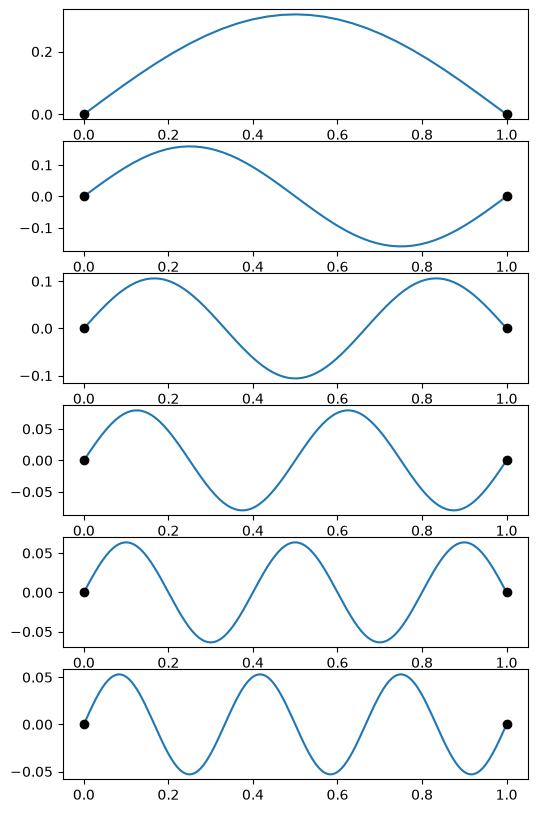

In [2]:
# First do the constant density string to check with the known frequencies
# and eigenfunctions

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    rho = 1
    dgdx = - omega**2 * rho * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (0,1), (0,1), 
                dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

fig = plt.figure(figsize = (6,10))

# We'll take advantage of the known frequencies for this case 
# to define the search windows
oms = np.pi * np.array((1,2,3,4,5,6))
num = len(oms)

for i, om in enumerate(oms):
    # search within 10% of the analytic frequency
    omega = scipy.optimize.brentq(do_integration, 0.9*om, 1.1*om)

    # once we have the frequency from the root find, redo the integration
    # to get the eigenfunction
    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), 
                dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

plt.show()

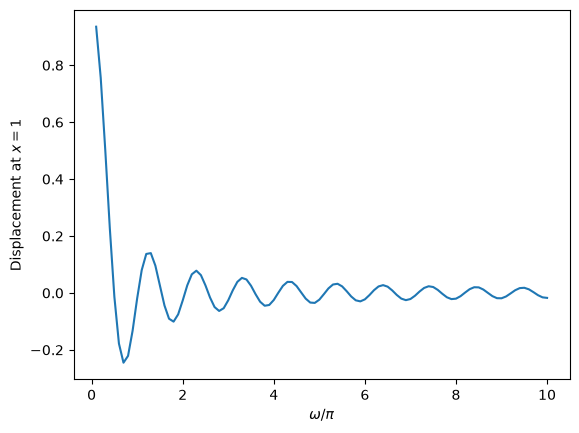

Frequency guesses= [0.4 1.  1.5 2.  2.5 3.  3.5 4.  4.6 5.1 5.6 6.1 6.6 7.1 7.6 8.1 8.7 9.2
 9.7]
Found omega = 0.493435 pi, n = 0
Found omega = 1.01754 pi, n = 1
Found omega = 1.53482 pi, n = 2
Found omega = 2.04889 pi, n = 3
Found omega = 2.5615 pi, n = 4
Found omega = 3.07348 pi, n = 5
Found omega = 3.58522 pi, n = 6
Found omega = 4.09688 pi, n = 7
Found omega = 4.60852 pi, n = 8
Found omega = 5.12018 pi, n = 9
Found omega = 5.63186 pi, n = 10
Found omega = 6.14356 pi, n = 11
Found omega = 6.65528 pi, n = 12
Found omega = 7.16701 pi, n = 13
Found omega = 7.67876 pi, n = 14
Found omega = 8.19051 pi, n = 15
Found omega = 8.70228 pi, n = 16
Found omega = 9.21405 pi, n = 17
Found omega = 9.72583 pi, n = 18


<Figure size 640x480 with 0 Axes>

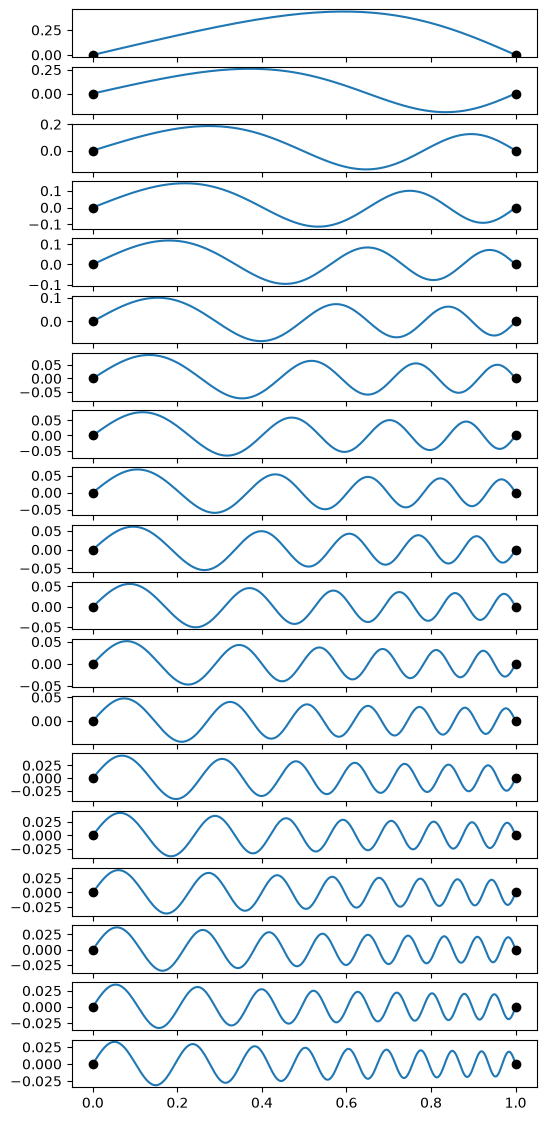

In [3]:
# Now do an x-dependent density
def rho(x):
    rho = 1.0 + 10*x**2
    #rho = np.ones_like(x)
    return rho

def derivs(x, y, omega):
    f, g = y
    dfdx = g
    dgdx = - omega**2 * rho(x) * f
    return dfdx, dgdx

def do_integration(omega):
    result = scipy.integrate.solve_ivp(derivs, (0,1), (0,1), 
                dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    return result.y[0,-1]

# Evaluate the displacement at x=1 on a grid of omega
# Search for modes between omega = 0 and 10 pi.
oms = np.pi * np.linspace(0.1,10,100)
result = np.array([do_integration(om) for om in oms]) 
plt.plot(oms/np.pi, result)
plt.xlabel(r'$\omega/\pi$')
plt.ylabel(r'Displacement at $x=1$')
plt.show()
# identify the zero-crossings as initial guesses for mode frequencies
inds = np.where(np.diff(np.sign(result)))[0]
print('Frequency guesses=', oms[inds]/np.pi)

plt.clf()
num = len(inds)
fig = plt.figure(figsize = (6,14))

# these arrays will be used to store the eigenmodes
x_s = []
f_s = []
om_s = []

for i, ind in enumerate(inds):
    omega = scipy.optimize.brentq(do_integration, oms[ind], oms[ind+1])

    result = scipy.integrate.solve_ivp(derivs, (1e-5,1), (0,1), 
                dense_output=True, args=(omega,), atol=1e-8, rtol=1e-8)
    x = result.t
    f = result.y[0]

    # find the number of zero crossings (not including the endpoints)
    n = ((f[1:-1] * f[:-2]) < 0).sum()
    print("Found omega = %lg pi, n = %d" % (omega/np.pi,n))

    plt.subplot(num,1,1+i)
    plt.plot(x, f)
    plt.plot((0,1),(0,0), 'ko')

    # Store the eigenfunctions to compare later with the relaxation result
    x_s.append(x)
    f_s.append(f)
    om_s.append(omega)

plt.show()


## Relaxation method for waves on a string

setting omega =  1.5501720260391922
|F|=7.63034e-16; Solve took 0.000789881 seconds


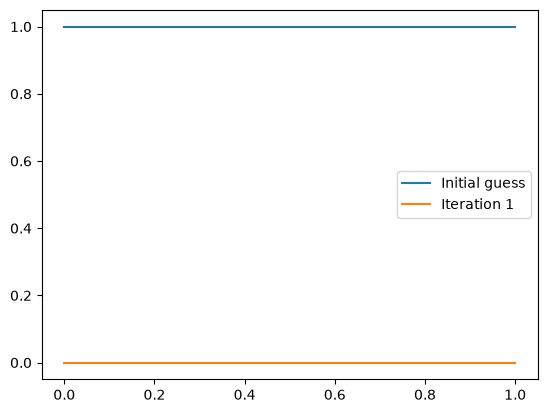

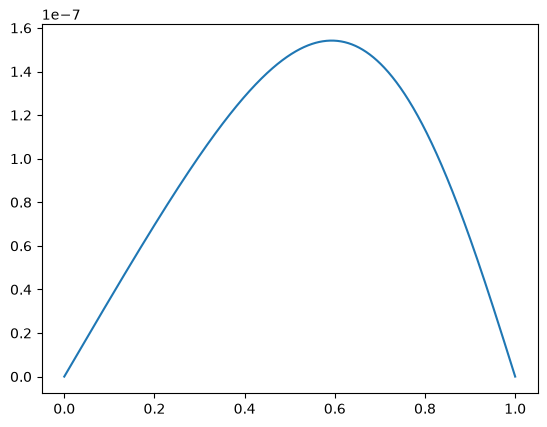

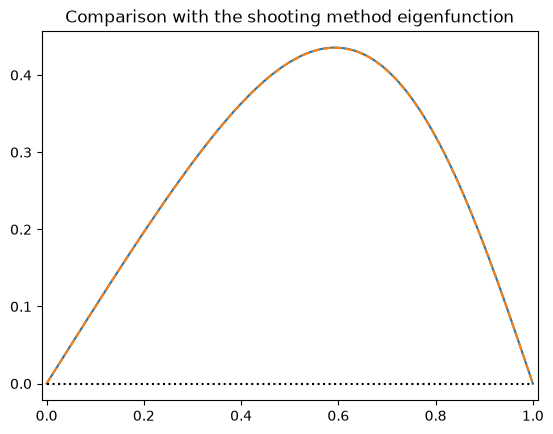

In [4]:
def calculate_F(f, x, omega):
    F = np.zeros(ngrid)
    dx = x[1]-x[0]  # assume constant spacing    
    F[1:-1] = f[2:] - (2 - dx**2 * omega**2 * rho(x[1:-1]))*f[1:-1] + f[:-2]
    F[0] = f[0]  #bc
    F[-1] = f[-1] #bc
    return F

# Calculate the Jacobian in banded form
def calculate_J_banded(f, x, omega):
    dx = x[1]-x[0]  # assume constant spacing

    a = np.ones_like(x)
    # a[0] is not used for the upper diagonal
    a[1] = 0  # bc

    b = - (2 - dx**2 * omega**2 * rho(x))
    b[0] = 1  #bc
    b[-1] = 1 #bc
    
    c = np.ones_like(x)
    # c[-1] is not used for the lower diagonal
    c[-2] = 0 # bc
    
    return np.vstack((a,b,c))
    
def rho(x):
    rho = 1.0 + 10*x**2
    #rho = np.ones_like(x)
    return rho

# Use the frequency from the shooting method:
nmode = 0  # which mode to compare to
omega = om_s[nmode]
print("setting omega = ", omega)
ngrid = 1000
x = np.linspace(0,1,ngrid)
dx = x[1]-x[0]

# Initial guess
f = np.ones_like(x)
plt.plot(x, f, label='Initial guess')

niter = 1
for m in range(niter):

    t0 = time.time()

    F = calculate_F(f, x, omega)
    J = calculate_J_banded(f, x, omega)
    df = -scipy.linalg.solve_banded((1,1), J, F)
    f = f + df
    
    print('|F|=%lg; Solve took %lg seconds' % 
            (max(abs(calculate_F(f,x,omega))),time.time()-t0,))
    plt.plot(x, f, label='Iteration %d' % (m+1,))

plt.legend()
plt.show()

# Plot the end result
plt.clf()
plt.plot(x,f)

# Plot the rescaled version compared to the shooting method
plt.figure()
# readjust normalization to keep df/dx=1 at x=0
f = f * dx/ (f[1]-f[0])
plt.plot(x,f)
plt.plot(x_s[nmode], f_s[nmode], "--")
plt.plot((0,1),(0,0),"k:")

plt.xlim((-0.01,1.01))
plt.title('Comparison with the shooting method eigenfunction')
plt.show()

What we see here is that one Newton step takes the solution almost to zero, except for the eigenmode we are looking for at very small amplitude. Normalizing the amplitude so that $df/dx=1$ at $x=0$ gives good agreement with the eigenfunction from the shooting method.

To understand why the solution goes to (almost) zero, note that because we are specifying the frequency $\omega$ in advance, we have a linear relation $\mathbf{F} = \mathbf{A}\mathbf{f}$ for this system, where $\mathbf{A}$ is a matrix of constant coefficients. The Jacobian $\mathbf{J} = \partial \mathbf{F}/\partial \mathbf{f}$ is then just the same as the matrix $\mathbf{A}$, so $\mathbf{F} = \mathbf{J}\mathbf{f}$. The Newton update is therefore
$$\Delta \mathbf{f} = -\mathbf{J}^{-1}\mathbf{F} = - \mathbf{J}^{-1}\mathbf{J}\mathbf{f} = -\mathbf{f}$$
and the update gives 
$$\mathbf{f}_\mathrm{new} = \mathbf{f} + \Delta\mathbf{f} = 0.$$
This is the cancellation that we see! 

There is a subtlety though: this argument should not work if we have chosen the frequency to be exactly one of the eigenvalues! The reason is that when $\omega$ is an eigenvalue, the matrix $\mathbf{J}$ should be singular (not invertible, $\mathrm{det}=0$) so that $\mathbf{J}\mathbf{f}_\mathrm{eigen}=0$ has a non-trivial solution for the eigenvector $\mathbf{f}_\mathrm{eigen}$. So formally, the argument we just gave should fail at the step where we use $\mathbf{J}^{-1}$. However, instead the algorithm is trying to get to the trivial solution $\mathbf{f}=0$. What is happening is that we have a discretized version of the problem, and the eigenvector from the shooting problem will be slightly different from the true eigenvalue of the matrix, so we do actually have an invertible matrix and the method is able to proceed. (Also, note that in general, methods for solving this kind of linear equation do so by various matrix manipulations that usually do not involve calculating the inverse directly and multipying by it, so this helps.)

So why are we left with a small residual solution correspond to the eigenvector? The answer is that the eigenvector lies in the *null space* of the matrix, i.e. the set of vectors that satisfy $\mathbf{J}\mathbf{f}=0$ (or at least very close to the null space since we don't have exactly the true eigenvalue). If we separate the initial guess into the eigenfunction we are looking for and the leftover part, $\mathbf{f} =c\mathbf{f}_\mathrm{eigen} + \sum_i c_i \mathbf{f}_i$ (where the sum is over the other eigenfunctions, $c$ and $\{c_i\}$ are constants), then 
$$\mathbf{F} = \mathbf{J}\mathbf{f} = \epsilon c\mathbf{f}_\mathrm{eigen} + \sum_i c_i \mathbf{J}\mathbf{f_i},$$
where $\epsilon$ would be zero if we had the exact eigenvalue, but because we are slightly off, we have $\epsilon$ small but non-zero. Because the eigenvector component has this tiny eigenvalue ($\mathbf{J}\mathbf{f}_\mathrm{eigen} = \epsilon \mathbf{f}_\mathrm{eigen}$), it makes the calculation of the inverse sensitive to numerical errors (since the corresponding component of the inverse is $\propto 1/\epsilon$). The algorithm tries to null out that component, but the matrix is nearly singular (we say that it is *ill-conditioned*) and while the other modes can be removed to high accuracy, the eigenmode is left with a small but significant residual. 

We'll discuss more about ill-conditioned linear systems later in the course, when we get to least-squares fitting.

### Alternative: include the frequency as a variable and add a normalization condition

It's probably good to avoid the almost exact cancellation that we get when setting $\omega$ in advance. A better way to deal with this is to add the normalization as an extra equation, and add the frequency $\omega$ as an extra variable to solve for. Here is how to do that:

nmode = 0, omega = 1.5501712077, omega/pi = 0.4934348207 (0.4934350812 shooting) 1 iterations
nmode = 1, omega = 3.1967040373, omega/pi = 1.0175424983 (1.0175448429 shooting) 2 iterations
nmode = 2, omega = 4.8217677768, omega/pi = 1.5348163522 (1.5348244068 shooting) 2 iterations
nmode = 3, omega = 6.4367132159, omega/pi = 2.0488694512 (2.0488886080 shooting) 2 iterations
nmode = 4, omega = 8.0470682823, omega/pi = 2.5614613890 (2.5614988237 shooting) 2 iterations
nmode = 5, omega = 9.6554303749, omega/pi = 3.0734189437 (3.0734836270 shooting) 2 iterations
nmode = 6, omega = 11.2629831988, omega/pi = 3.5851189001 (3.5852216040 shooting) 3 iterations
nmode = 7, omega = 12.8702424382, omega/pi = 4.0967254057 (4.0968787024 shooting) 2 iterations
nmode = 8, omega = 14.4774177558, omega/pi = 4.6083051981 (4.6085234571 shooting) 2 iterations
nmode = 9, omega = 16.0845836057, omega/pi = 5.1198819769 (5.1201813667 shooting) 2 iterations
nmode = 10, omega = 17.6917573720, omega/pi = 5.63146127

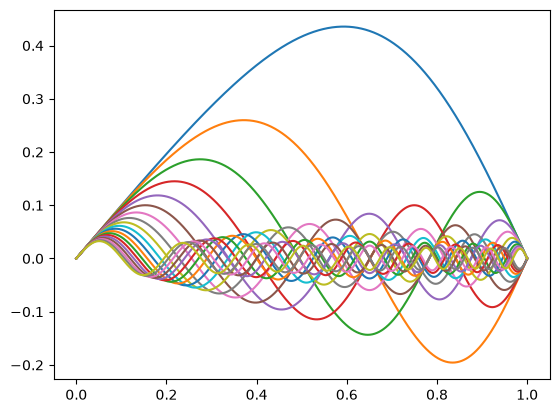

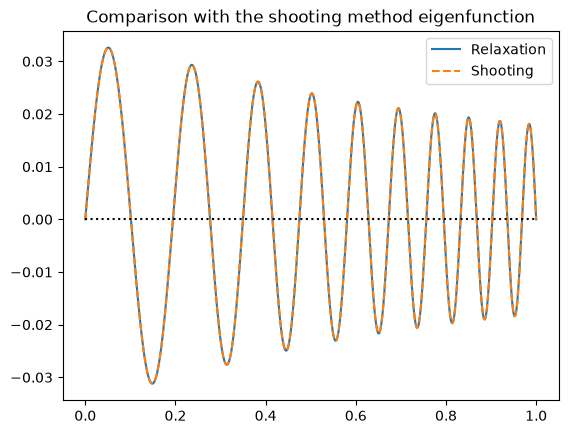

In [5]:
import scipy.sparse

def calculate_F(f, x, om):
    # same as before but add an extra equation for the normalization
    F = np.zeros(ngrid+1)
    dx = x[1]-x[0]  # assume constant spacing    
    F[1:ngrid-1] = f[2:] - (2 - dx**2 * om**2 * rho(x[1:-1]))*f[1:-1] + f[:-2]
    F[0] = f[0]  #bc
    F[ngrid-1] = f[-1] #bc
    F[ngrid] = f[1] - f[0] - dx #normalization
    return F

# Calculate the Jacobian
def calculate_J(f, x, om):
    dx = x[1]-x[0]  # assume constant spacing

    # First compute the main part of the matrix
    a = np.ones(ngrid-1)
    a[0] = 0  # bc
    b = - (2 - dx**2 * om**2 * rho(x))
    b[0] = 1  #bc
    b[-1] = 1 #bc
    c = np.ones(ngrid-1)
    c[-1] = 0 # bc
    A = scipy.sparse.diags([c,b,a],[-1,0,1])

    # Now the column for dF/domega
    dFdom = 2 * dx**2 * om * rho(x) * f
    dFdom[0] = 0
    dFdom[-1] = 0
    # make into a column vector
    col = dFdom.reshape(-1, 1)

    # normalization row: d(f[1]-f[0]-dx)/df
    norm = np.zeros(ngrid)
    norm[0] = -1
    norm[1] = 1

    return scipy.sparse.block_array([[A, col], [norm, None]], format='csc')

# --- setup ---
ngrid = 1000
x = np.linspace(0, 1, ngrid)
dx = x[1] - x[0]

plt.figure()

for nmode in range(0,19):
    # use the frequency from the shooting calculation for this mode
    omega = om_s[nmode]
    # but for the eigenfunction, just try a sinusoidal initial guess
    f = np.sin((nmode+1)*np.pi*x/2)

    for i in range(10):
        F = calculate_F(f, x, omega)
        J = calculate_J(f, x, omega)
        df = scipy.sparse.linalg.spsolve(J, -F)
        f = f + df[:-1]
        omega = omega + df[-1]
        if np.max(np.abs(df)) < 1e-6:
            break

    plt.plot(x,f)
    
    print('nmode = %d, omega = %.10f, omega/pi = %.10f (%.10f shooting) %d iterations' 
          % (nmode, omega, omega/np.pi, om_s[nmode]/np.pi, i))

plt.figure()
plt.plot(x, f, label='Relaxation')
plt.plot(x_s[-1], f_s[-1], '--', label='Shooting')
plt.plot((0, 1), (0, 0), 'k:')
plt.legend()
plt.title('Comparison with the shooting method eigenfunction')
plt.show()

## Waves on a string using `scipy.linalg.eigh'

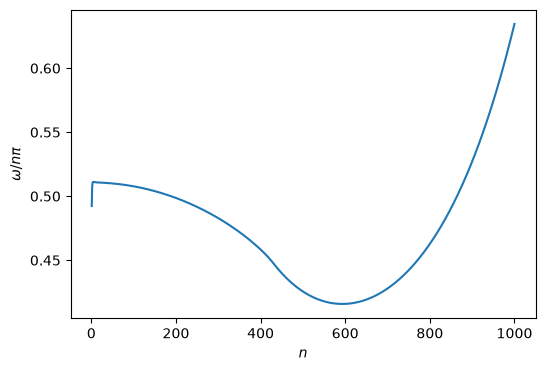

<Figure size 640x480 with 0 Axes>

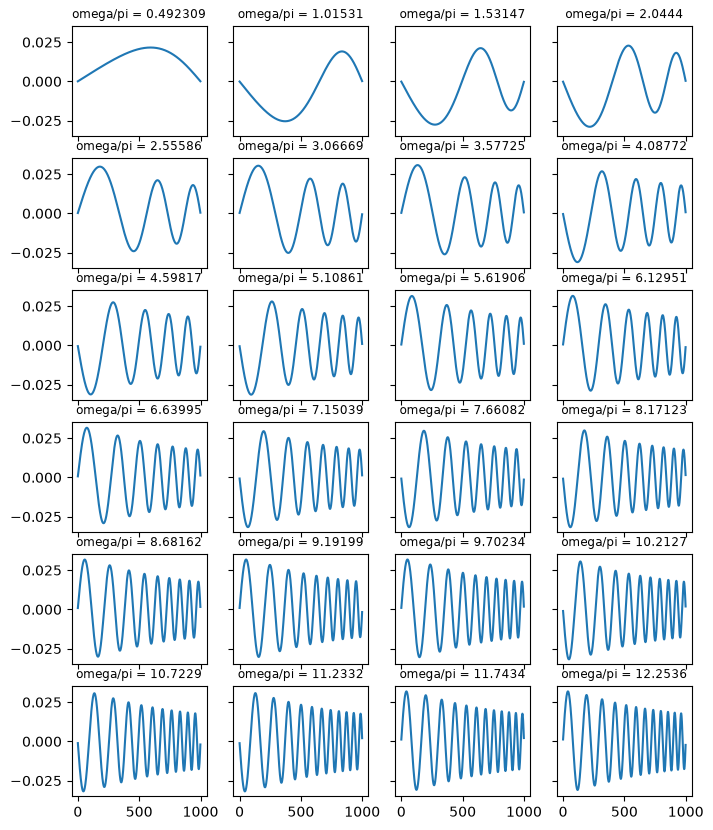

In [6]:
n = 1000
x = np.linspace(0,1,n)
dx = x[1]-x[0]  # grid spacing

A = np.diag(2*np.ones(n), k=0) + \
    np.diag(-np.ones(n-1),k=-1) + \
    np.diag(-np.ones(n-1),k=1)
# Get the eigenvalues and eigenvectors 
w2, v = scipy.linalg.eigh(A, b=np.diag(rho(x)))
# constant density
#w2, v = scipy.linalg.eigh(A, b=np.diag(np.ones_like(x)))

w2 = w2 / dx**2
w=np.sqrt(w2)/np.pi

i = np.arange(len(w)) + 1
plt.figure(figsize=(6,4))
plt.plot(i, w/i)
plt.ylabel(r'$\omega/n\pi$')
plt.xlabel(r'$n$')
plt.show()
plt.clf()

# Note that the n-th eigenvector is given by v[:, n-1] (not v[n-1]!)
fig, ax = plt.subplots(6, 4, sharex='all', sharey='all', figsize=(8,10))
for i in range(24):
    ax[i//4, i%4].plot(np.arange(len(v[:,i])), v[:,i])
    ax[i//4, i%4].set_title("omega/pi = %lg" % (w[i]), fontsize='small')


## Laplace's equation: Jacobi method

The basic idea here is that the solution diffuses in from the boundaries (the Laplacian operator is the same operator we had in the diffusion equation). Diffusion over a lengthscale $L$ takes a time $t_\mathrm{diff}\approx L^2/D$ where $D$ is the diffusion coefficient. In the Jacobi update, the "timestep" we are using corresponds to $\alpha=1/4$ in the explicit diffusion method, i.e. $\Delta t=(\Delta x)^2/4D$ (the maximum stable timestep). Therefore, the number of timesteps needed for the solution to diffuse a distance $L$ is approximately
$$n_\mathrm{iter}\approx {L^2/D\over (\Delta x)^2/4D} = 4\left({L\over \Delta x}\right)^2.$$
To fill in the region between the centre of the box and the edge, we need to diffuse $1/4$ of the way across the box, so let's take $L\approx n_\mathrm{grid} \Delta x/4$, which gives $n_\mathrm{iter}\approx n_\mathrm{grid}^2/4$.
In the plots below, this is shown by the vertical dashed line, and is in rough agreement with the point at which $\Delta V$ starts to decrease more rapidly.

In [7]:
def set_bcs(n):
    # Create a mask to set the boundary points
    # (following https://github.com/sievers/phys512-2022/tree/master/pdes )
    
    # create a 2D array filled with the value of r, distance from the center
    x = np.linspace(-1,1,n)
    xsqr = np.outer(x**2,np.ones(n))
    rsqr = xsqr+xsqr.T
    # this will be the size of the central circle
    R = 0.1
    
    # points in the mask that are True correspond to boundary points
    mask = np.zeros([n,n],dtype='bool')
    mask[rsqr<R**2] = True
    mask[:,0] = True
    mask[0,:] = True
    mask[-1,:] = True
    mask[:,-1] = True
    
    # bc contains the values of V in the boundary points
    bc = np.zeros([n,n])
    bc[rsqr < R**2] = 1.0

    return mask, bc

def laplace(mask, bc, niter, V, make_plot=True):
    # implements the Jacobi method to solve Laplace's equation
    V = V.copy()
    
    # keep track of how much V changes from one iteration to the next
    deltaV = np.zeros(niter)
    
    t0 = time.time()
    for i in range(niter):
        
        # Jacobi update
        Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + 
                       np.roll(V,1,1) + np.roll(V,-1,1))
        # Now reapply the boundary conditions
        Vnew[mask] = bc[mask]
        # Store how much V changed this iteration
        deltaV[i] = np.max(np.abs(Vnew-V))
        V = Vnew
    
        if (i+1)%1000 == 0 and make_plot:
            n = len(V[0,:])
            plt.plot(np.arange(n), V[n//2,:])

    print('n=%d : %d iterations took %lg seconds' %(len(V[0,:]), niter, time.time()-t0))

    return V, deltaV

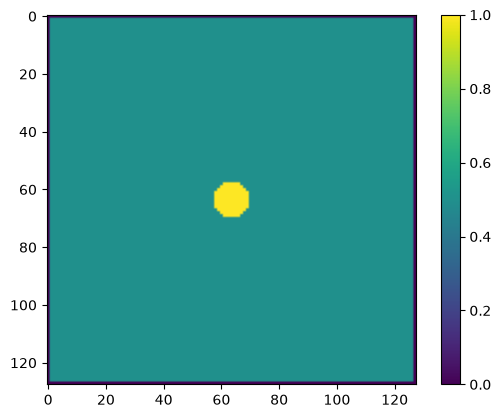

n=128 : 32768 iterations took 1.32334 seconds


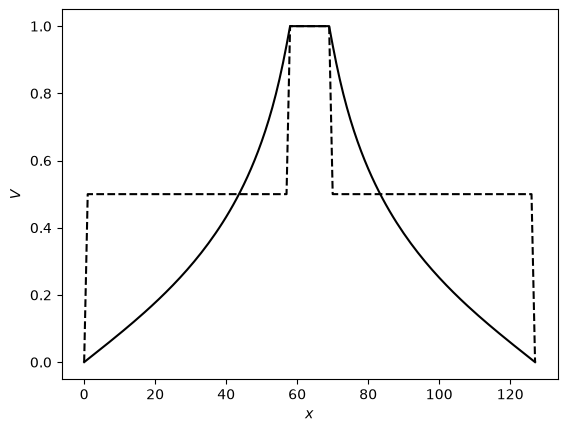

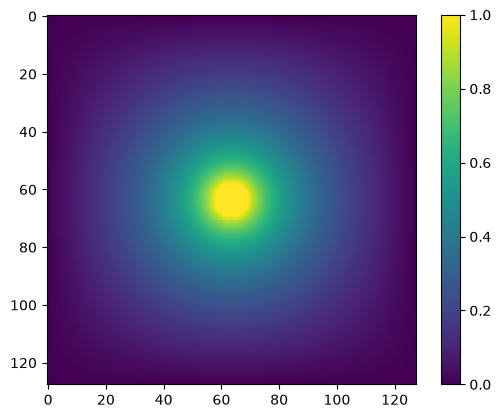

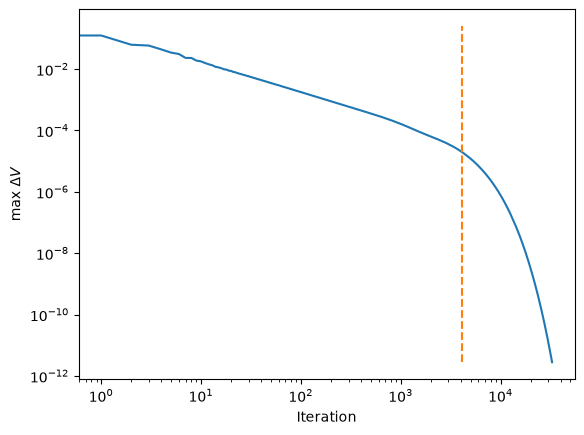

In [8]:
# Solve Laplace's equation with Jacobi method
n = 128  # number of grid points (n x n grid)
niter = 2 * n**2 # number of iterations
mask, bc = set_bcs(n)

# Initial guess for the potential 
V = np.zeros([n,n]) + 0.5
V[mask] = bc[mask]

plt.imshow(V)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(n), V[int(n/2),:], 'k--')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')
V_jacobi, deltaV_jacobi = laplace(mask, bc, niter, V, make_plot=False)

plt.plot(np.arange(n), V_jacobi[int(n/2),:], 'k')
plt.show()

plt.clf()
plt.imshow(V_jacobi)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi)
plt.plot([n**2/4,n**2/4],[np.min(deltaV_jacobi),np.max(deltaV_jacobi)],"--")
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.show()

I ran this a few times and got the following:
```
n=128 : 32768 iterations took 1.35271 seconds
n=256 : 131072 iterations took 17.0591 seconds
n=512 : 524288 iterations took 238.692 seconds
```

This is a factor 13 or 14 times longer for a factor of 2 increase in $n$, so almost $\propto n^4$. We need to take $n^2$ more timesteps but each step also takes longer because we are dealing with larger matrices (there are $n^2$ values to update).


## Laplace's equation: multigrid

In [9]:
# A simple way to decrease or increase the number of grid points by a factor of 2
# From https://github.com/sievers/phys512-2022/tree/master/pdes

def deres(map):
    tmp = np.maximum(map[::2,::2],map[1::2,::2])
    tmp = np.maximum(tmp,map[::2,1::2])
    tmp = np.maximum(tmp,map[1::2,1::2])
    return tmp

def upres(map):
    n = map.shape[0]
    tmp = np.zeros([2*n,2*n])
    tmp[::2,::2] = map
    tmp[1::2,::2] = map
    tmp[::2,1::2] = map
    tmp[1::2,1::2] = map
    return tmp

# Visualize matrices as a color map
def plot_matrices(A, titles=[], nmax=4):
    n = len(A)
    if titles==[]:
        titles = [""]*n
    if n>nmax:
        nx = nmax
    else:
        nx = n
    for j in range(int(np.floor(n/nmax))+1):        
        plt.clf()
        plt.figure(figsize=(nx*4,4))
        jmax = nmax*(j+1)
        if jmax > n:
            jmax = n
        for i,AA in enumerate(A[nmax*j:jmax]):
            plt.subplot(1, nx, i+1)
            plt.imshow(AA)
            plt.colorbar()
            plt.title(titles[nmax*j + i])
        plt.show()

n=128 : 32768 iterations took 1.41188 seconds
n=16 : 100 iterations took 0.00174594 seconds
n = 16, Delta V = 0.000255252
n=32 : 100 iterations took 0.0018878 seconds
n = 32, Delta V = 0.00054352
n=64 : 100 iterations took 0.00228691 seconds
n = 64, Delta V = 0.000653078


<Figure size 640x480 with 0 Axes>

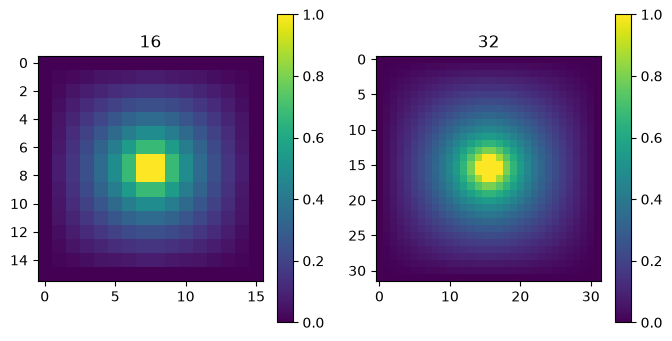

<Figure size 640x480 with 0 Axes>

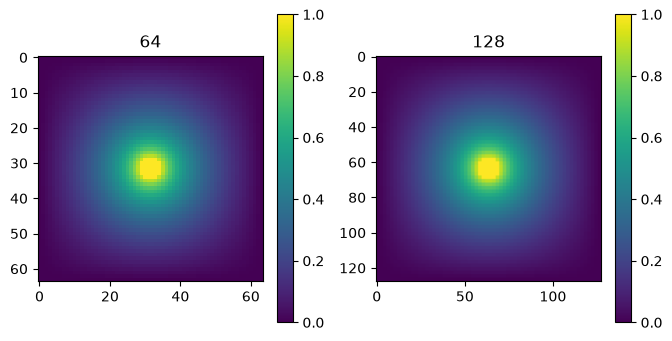

<Figure size 640x480 with 0 Axes>

<Figure size 800x400 with 0 Axes>

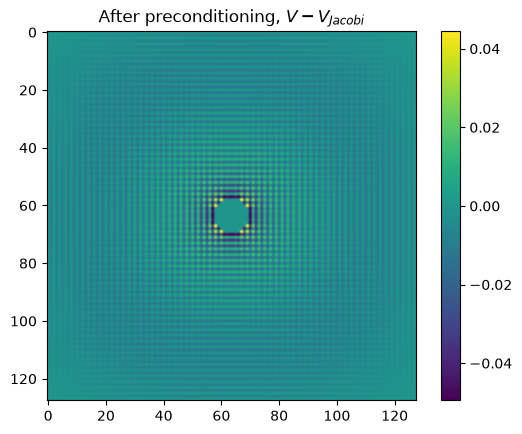

n=128 : 32768 iterations took 1.32164 seconds
n = 128, Delta V = 5.16809e-14


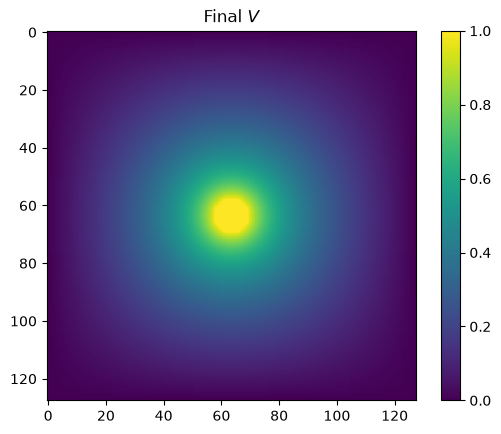

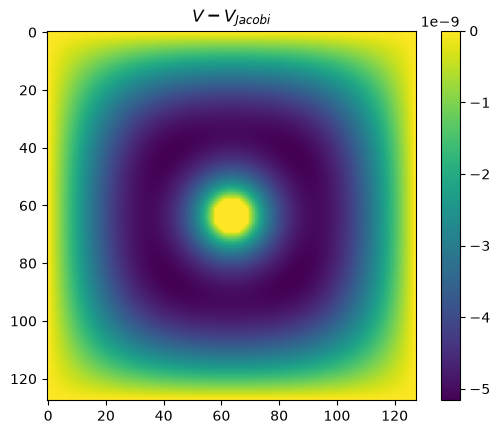

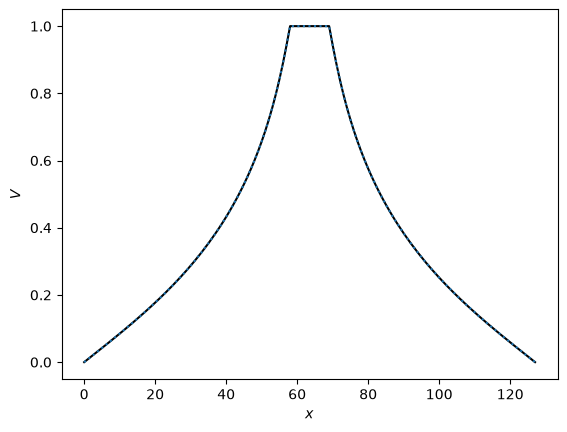

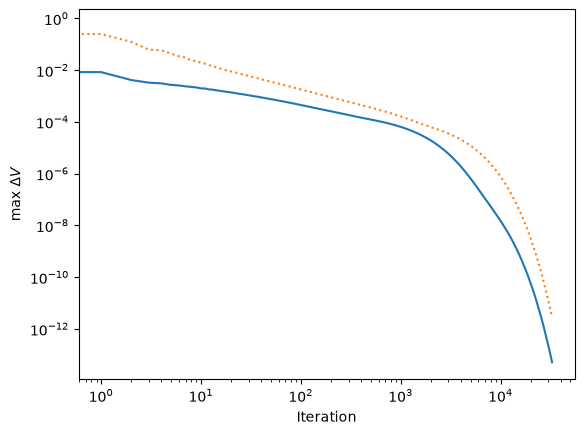

In [10]:
# Solve Laplace's equation with a multigrid method
n = 128
mask, bc = set_bcs(n)
# Initial guess for the potential
V0 = np.ones_like(bc) * 0.5

# First do Jacobi
V_jacobi, deltaV_jacobi = laplace(mask, bc, 2*n*n, V0, make_plot=False)

# First go down in resolution from fine to coarse
# and calculate the smoothed bc, mask and V arrays at each step
npass = 3
bcs = [bc,]
masks = [mask,]
Vs = [V0,]
for i in range(npass):
    bcs.append(deres(bcs[i]))
    masks.append(deres(masks[i]))
    Vs.append(deres(Vs[i]))

# Now step back up, relaxing at each stage    
for i in range(npass,0,-1):
    n0 = bcs[i].shape[0]
    Vs[i], deltaV = laplace(masks[i], bcs[i], 100, Vs[i], make_plot=False)
    print('n = %d, Delta V = %lg' % (n0, deltaV[-1],))
    Vs[i-1] = upres(Vs[i])

# Plot the V arrays for each stage
titles = ["%d" % (V.shape[0],) for V in Vs]
plot_matrices(Vs[::-1], nmax = 2, titles=titles[::-1])


plt.clf()
plt.title(r'After preconditioning, $V-V_{Jacobi}$')
plt.imshow(Vs[0]-V_jacobi)
plt.colorbar()
plt.show()

# Run the final grid for 2*n*n interations so that we can see how it converges
# now that the solution has been preconditioned
n0 = bcs[0].shape[0]
nn = 2*n0*n0
Vs[0], deltaV = laplace(masks[0], bcs[0], nn, Vs[0], make_plot=False)
print('n = %d, Delta V = %lg' % (n0, deltaV[-1],))

plt.clf()
plt.title(r'Final $V$')
plt.imshow(Vs[0])
plt.colorbar()
plt.show()

plt.clf()
plt.title(r'$V-V_{Jacobi}$')
plt.imshow(Vs[0]-V_jacobi)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(n), Vs[0][int(n/2),:], 'k')
plt.plot(np.arange(n), V_jacobi[int(n/2),:], ':')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV)), deltaV)
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi, ':')
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.show()

The last plot shows that the multigrid method (blue curve in the final plot) converges more quickly than the Jacobi method (orange dotted line). In particular, we can now get a much more reasonable low-accuracy solution in the first part of the curve (number of iterations << n^2). Whereas previously these solutions were completely wrong because the diffusion from the boundaries had travelled only a small distance, now the coarse grids have taken care of the global diffusion and so the overall solution is much more accurate.

The general idea of using some approximate scheme to improve the initial guess for a relaxation method is known as **preconditioning**, and is used in many codes. Here, we can think of the sequence of low resolution grids as a preconditioner for the final relaxation at full resolution.

## Laplace's equation: successive over-relaxation

In [11]:
def laplace2(mask, bc, niter, V, make_plot=True, w=1, jacobi=True):
    # implements iterative methods to solve Laplace's equation
    V = V.copy()

    # create masks for the Gauss-Seidel chess board
    even = (np.indices(V.shape).sum(axis=0) % 2 == 0) # True for the black squares
    odd = ~even  # True for the white squares
    # remove the boundary points from these masks so the boundaries won't be updated
    even &= ~mask
    odd &= ~mask
    
    # keep track of how much V changes from one iteration to the next
    deltaV = np.zeros(niter)
    
    t0 = time.time()
    for i in range(niter):
        
        if jacobi:
            # Jacobi update
            Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + np.roll(V,1,1) + np.roll(V,-1,1))
            # Now reapply the boundary conditions
            Vnew[mask] = bc[mask]
            deltaV[i] = np.max(np.abs(Vnew-V))
            V = Vnew
        else:
            Vold = V.copy()
            # Gauss Seidel
            # even update
            Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + np.roll(V,1,1) + np.roll(V,-1,1))
            V[even] = (1-w)*V[even] + w*Vnew[even]            
            # odd update
            Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + np.roll(V,1,1) + np.roll(V,-1,1))
            V[odd] = (1-w)*V[odd] + w*Vnew[odd]

            deltaV[i] = np.max(np.abs(V-Vold))
            
        if (i+1)%100 == 0 and make_plot:
            n = len(V[0,:])
            plt.plot(np.arange(n), V[n//2,:])

        if deltaV[i] < 1e-8:
            niter = i+1
            break

    print('n=%d : %d iterations took %lg seconds' %(len(V[0,:]), niter, time.time()-t0))

    return V, deltaV

n=128 : 17895 iterations took 0.702869 seconds
n=128 : 9578 iterations took 2.6891 seconds
n=128 : 1263 iterations took 0.374237 seconds


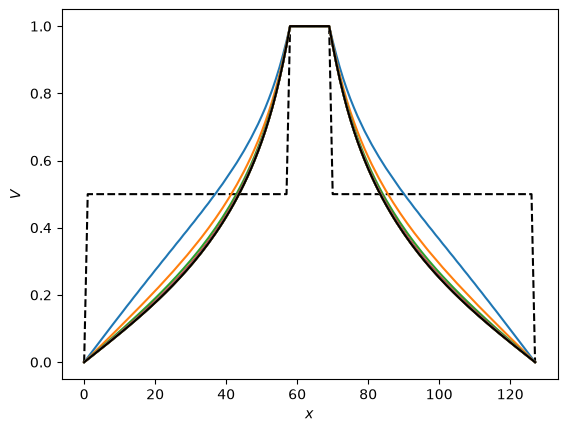

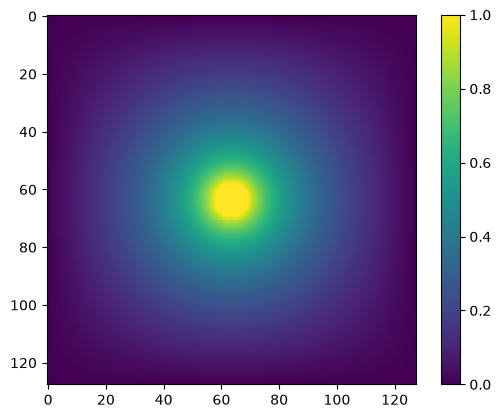

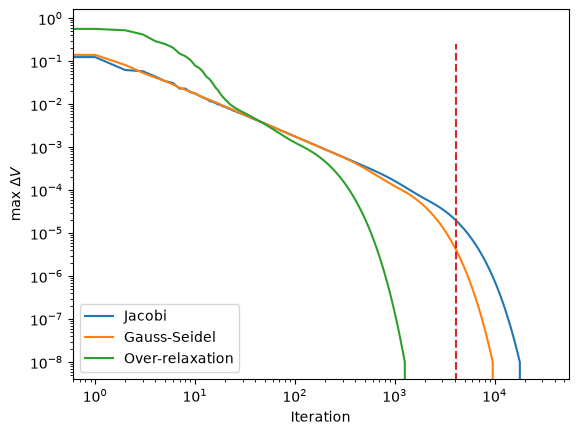

In [12]:
# Solve Laplace's equation with Jacobi method
n = 128  # number of grid points (n x n grid)
niter = 2 * n**2 # number of iterations
mask, bc = set_bcs(n)

# Initial guess for the potential 
V = np.zeros([n,n]) + 0.5
V[mask] = bc[mask]

#plt.imshow(V)
#plt.colorbar()
#plt.show()

plt.clf()
plt.plot(np.arange(n), V[int(n/2),:], 'k--')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')
V_jacobi, deltaV_jacobi = laplace2(mask, bc, niter, V, make_plot=False)
V_gauss, deltaV_gauss = laplace2(mask, bc, niter, V, w=1.0, jacobi=False, make_plot=False)
V_sor, deltaV_sor = laplace2(mask, bc, niter, V, w=1.8, jacobi=False, make_plot=True)

plt.plot(np.arange(n), V_sor[int(n/2),:], 'k')
plt.show()

plt.clf()
plt.imshow(V_sor)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi, label='Jacobi')
plt.plot(np.arange(len(deltaV_gauss)), deltaV_gauss, label='Gauss-Seidel')
plt.plot(np.arange(len(deltaV_sor)), deltaV_sor, label='Over-relaxation')
plt.plot([n**2/4,n**2/4],[np.min(deltaV_jacobi),np.max(deltaV_jacobi)],"--")
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.legend()
plt.show()

## Laplace's equation by conjugate gradient method

In [13]:
def conjgrad_laplace(x, b, n, mask, niter = 20):
    # Find a solution to Ax=b

    # Calculate first residual r_0 and set p_0 equal to it
    r = b - Ax(x, n, mask)
    p = r.copy()

    rr = r@r

    delta_x = np.zeros(niter)
    for i in range(niter):
        Ap = Ax(p, n, mask)
        pAp = p@Ap
        alpha = rr / pAp
        x = x + alpha*p
        r = r - alpha*Ap

        # keep track of how much x changes as a measure of convergence
        delta_x[i] = np.max(np.abs(alpha*p))

        rr_new = r@r
        beta = rr_new / rr
        p = r + beta*p

        rr = rr_new
        if i%(niter//10) == 0:
            print('Iteration %d: pAp = %lg, residual=%lg' % (1+i, pAp, rr**0.5))

        if delta_x[i] < 1e-8:
            break

    if i%(niter//10):
        print('Iteration %d: pAp = %lg, residual=%lg' % (1+i, pAp, rr**0.5))
    
    return x, delta_x

def Ax(x, n, mask):
    V = x.copy()
    V = V.reshape((n,n))
    # We set the boundary values to zero so that boundary points do not contribute to the
    # averaging. This is taken care of by the b vector
    V[mask] = 0
    Vnew = V - 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + 
                       np.roll(V,1,1) + np.roll(V,-1,1))
    Vnew[mask] = 0
    Vnew = Vnew.reshape(n*n)
    return Vnew

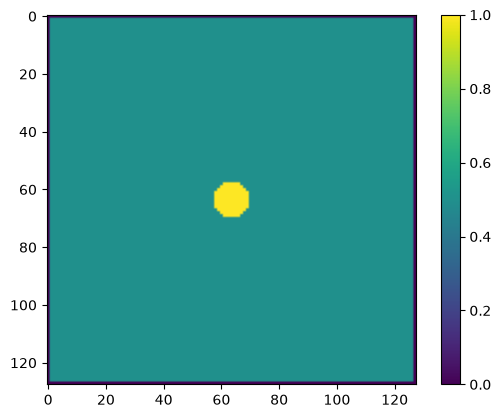

Iteration 1: pAp = 5, residual=1.73971
Iteration 26: pAp = 0.0174233, residual=0.178848
Iteration 51: pAp = 0.00228313, residual=0.0636708
Iteration 76: pAp = 0.00101965, residual=0.045664
Iteration 101: pAp = 0.000151638, residual=0.0146079
Iteration 126: pAp = 6.39377e-06, residual=0.0033452
Iteration 151: pAp = 3.77838e-08, residual=0.000237782
Iteration 176: pAp = 1.11364e-10, residual=1.1724e-05
Iteration 201: pAp = 5.59986e-13, residual=8.38435e-07
Iteration 217: pAp = 8.04286e-15, residual=8.92455e-08


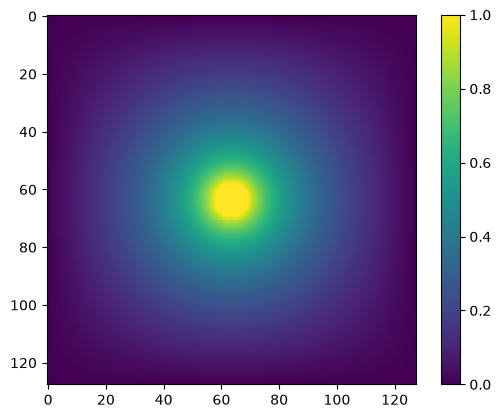

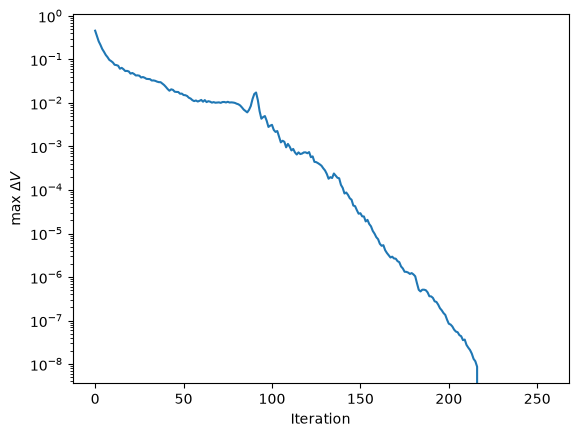

In [14]:
# Solve Laplace's equation with conjugate gradient
n = 128
#mask, bc = set_bcs_capacitor(n)
mask, bc = set_bcs(n)

# Initial guess for the potential 
V = np.zeros([n,n]) + 0.5
V[mask] = bc[mask]

plt.imshow(V)
plt.colorbar()
plt.show()

# The matrix bc has zeros in the interior points and the boundary condition
# values in the boundary points. We calculate the part of the averaging 
# that includes the boundary separately and then move it onto the right hand side
# as our b vector
b = 0.25 * (np.roll(bc,1,axis=0)+np.roll(bc,-1,axis=0)+
            np.roll(bc,1,axis=1)+np.roll(bc,-1,axis=1))
b[mask] = 0
b = b.reshape(n*n)

# This is the initial guess for the potential
x = V.reshape(n*n)

# Solve and then reshape into a 2D grid
x, delta_x = conjgrad_laplace(x, b, n, mask, niter = 2*n)
V = x.reshape((n,n))

plt.clf()
plt.imshow(V)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(len(delta_x)), delta_x)
plt.ylabel(r'max $\Delta V$')
plt.xlabel(r'Iteration')
plt.yscale('log')
#plt.xscale('log')
plt.show()

## Laplace's equation: All methods compared

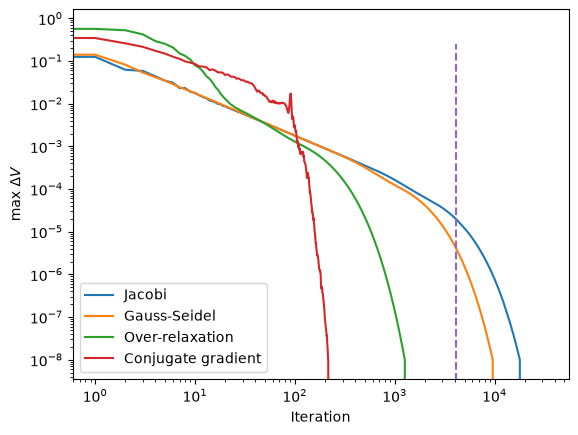

In [15]:
# Compare all methods
plt.clf()
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi, label='Jacobi')
plt.plot(np.arange(len(deltaV_gauss)), deltaV_gauss, label='Gauss-Seidel')
plt.plot(np.arange(len(deltaV_sor)), deltaV_sor, label='Over-relaxation')
plt.plot(np.arange(len(delta_x)), delta_x, label='Conjugate gradient')
plt.plot([n**2/4,n**2/4],[np.min(deltaV_jacobi),np.max(deltaV_jacobi)],"--")
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.legend()
plt.show()